In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [62]:
sim_data = pd.read_csv('..\Dataset\simulation_matrix_updated_info.csv')
sim_data

,ID,Blade_Length_m,Root_Chord_mm,Material,Applied_Load_Pa,Status,Max_Deformation_m,Max_Equiv_Stress_Pa
0,BL0.8_C150_AL_P500,0.8,150,Aluminium,500,Updated,0.002438,4.2995 E+06
1,BL0.8_C150_AL_P1000,0.8,150,Aluminium,1000,Updated,0.004875,8.5991 E+06
2,BL0.8_C150_AL_P1500,0.8,150,Aluminium,1500,Updated,0.007313,1.2899 E+07
3,BL0.8_C150_FBG_P500,0.8,150,Fiberglass,500,Updated,0.006742,4.3042 E+06
4,BL0.8_C150_FBG_P1000,0.8,150,Fiberglass,1000,Updated,0.013483,8.6085 E+06
...,...,...,...,...,...,...,...,...
76,BL1.6_C300_FBG_P1000,1.6,300,Fiberglass,1000,Updated,0.027693,8.6208 E+06
77,BL1.6_C300_FBG_P1500,1.6,300,Fiberglass,1500,Updated,0.041539,1.2931 E+07
78,BL1.6_C300_CBF_P500,1.6,300,Carbon fiber,500,Updated,0.002883,4.3078 E+06
79,BL1.6_C300_CBF_P1000,1.6,300,Carbon fiber,1000,Updated,0.005766,8.6156 E+06


In [63]:
sim_data["Max_Equiv_Stress_Pa"] = sim_data["Max_Equiv_Stress_Pa"].astype(str).str.replace(" ", "")

sim_data = sim_data[sim_data["Status"] == "Updated"].copy()
sim_data["Max_Deformation_m"] = pd.to_numeric(sim_data["Max_Deformation_m"])
sim_data["Max_Equiv_Stress_Pa"] = pd.to_numeric(sim_data["Max_Equiv_Stress_Pa"])

# Convenient unit conversions
sim_data["Deformation_mm"] = sim_data["Max_Deformation_m"] * 1000
sim_data["Stress_MPa"] = sim_data["Max_Equiv_Stress_Pa"] / 1e6

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

print(f"Completed simulations: {len(sim_data)}")
sim_data

Completed simulations: 81


,ID,Blade_Length_m,Root_Chord_mm,Material,Applied_Load_Pa,Status,Max_Deformation_m,Max_Equiv_Stress_Pa,Deformation_mm,Stress_MPa
0,BL0.8_C150_AL_P500,0.8,150,Aluminium,500,Updated,0.002438,4299500.0,2.4376,4.2995
1,BL0.8_C150_AL_P1000,0.8,150,Aluminium,1000,Updated,0.004875,8599100.0,4.8752,8.5991
2,BL0.8_C150_AL_P1500,0.8,150,Aluminium,1500,Updated,0.007313,12899000.0,7.3129,12.8990
3,BL0.8_C150_FBG_P500,0.8,150,Fiberglass,500,Updated,0.006742,4304200.0,6.7417,4.3042
4,BL0.8_C150_FBG_P1000,0.8,150,Fiberglass,1000,Updated,0.013483,8608500.0,13.4830,8.6085
...,...,...,...,...,...,...,...,...,...,...
76,BL1.6_C300_FBG_P1000,1.6,300,Fiberglass,1000,Updated,0.027693,8620800.0,27.6930,8.6208
77,BL1.6_C300_FBG_P1500,1.6,300,Fiberglass,1500,Updated,0.041539,12931000.0,41.5390,12.9310
78,BL1.6_C300_CBF_P500,1.6,300,Carbon fiber,500,Updated,0.002883,4307800.0,2.8829,4.3078
79,BL1.6_C300_CBF_P1000,1.6,300,Carbon fiber,1000,Updated,0.005766,8615600.0,5.7658,8.6156


In [64]:
# Material Encoding 
# label encoding, only for correlation analysis

material_map = { 'Aluminium' : 0, 'Fiberglass' : 1, 'Carbon fiber' : 2}

sim_data["Material_enc"] = sim_data["Material"].map(material_map)

corr_cols = ["Blade_Length_m", "Root_Chord_mm", "Material_enc",
             "Applied_Load_Pa", "Max_Deformation_m", "Max_Equiv_Stress_Pa"]
corr_matrix = sim_data[corr_cols].corr()
corr_matrix.round(3)

,Blade_Length_m,Root_Chord_mm,Material_enc,Applied_Load_Pa,Max_Deformation_m,Max_Equiv_Stress_Pa
Blade_Length_m,1.000,-0.000,-0.000,-0.000,0.458,0.549
Root_Chord_mm,-0.000,1.000,-0.000,-0.000,-0.356,-0.530
Material_enc,-0.000,-0.000,1.000,-0.000,-0.066,0.000
Applied_Load_Pa,-0.000,-0.000,-0.000,1.000,0.226,0.441
Max_Deformation_m,0.458,-0.356,-0.066,0.226,1.000,0.753
Max_Equiv_Stress_Pa,0.549,-0.530,0.000,0.441,0.753,1.000


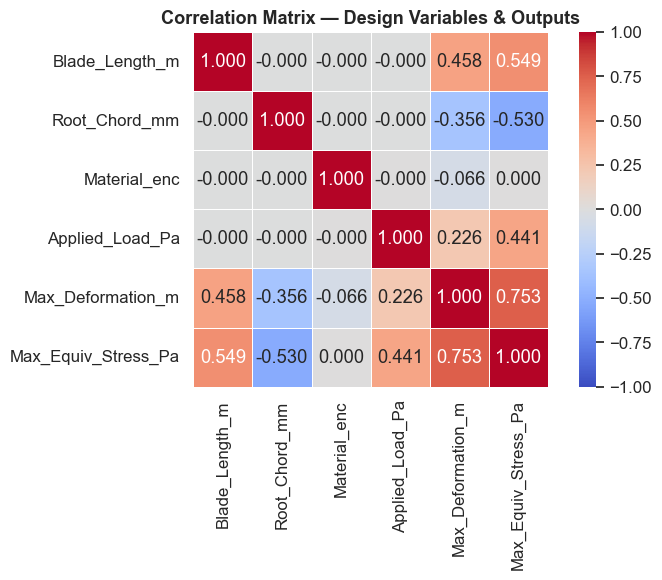

In [65]:
# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix — Design Variables & Outputs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [66]:
# feature ranking by correlation
stress_rank = corr_matrix["Max_Equiv_Stress_Pa"].drop(["Max_Equiv_Stress_Pa", "Max_Deformation_m"]).abs().sort_values(ascending=False)
defo_rank = corr_matrix["Max_Deformation_m"].drop(["Max_Equiv_Stress_Pa", "Max_Deformation_m"]).abs().sort_values(ascending=False)

print("Stress ranking:\n", stress_rank)
print("\nDeformation ranking:\n", defo_rank)

Stress ranking:
 Blade_Length_m     0.549281
Root_Chord_mm      0.529777
Applied_Load_Pa    0.441254
Material_enc       0.000123
Name: Max_Equiv_Stress_Pa, dtype: float64

Deformation ranking:
 Blade_Length_m     0.458144
Root_Chord_mm      0.356259
Applied_Load_Pa    0.226191
Material_enc       0.066420
Name: Max_Deformation_m, dtype: float64


# Power Law Check

Font 'default' does not have a glyph for '\u221d' [U+221d], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u221d' [U+221d], substituting with a dummy symbol.


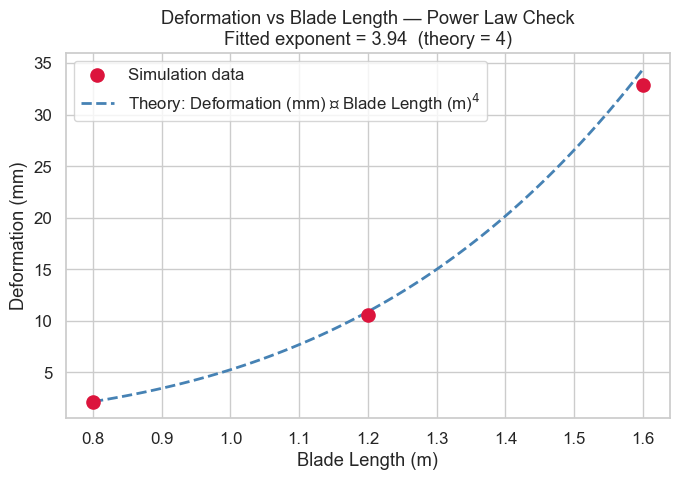

Font 'default' does not have a glyph for '\u221d' [U+221d], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u221d' [U+221d], substituting with a dummy symbol.


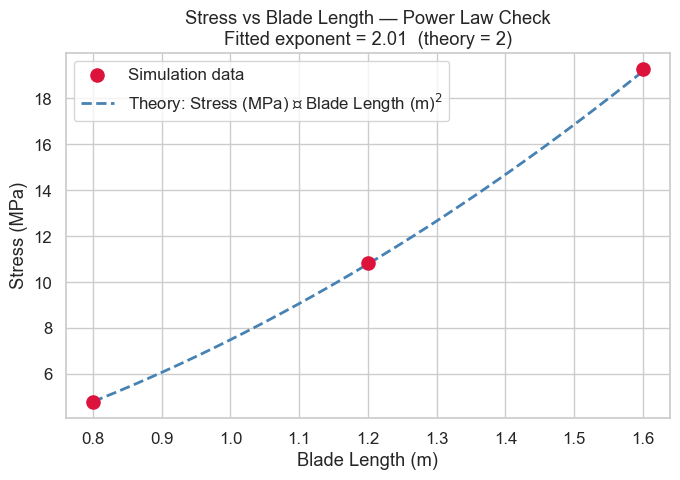

Font 'default' does not have a glyph for '\u221d' [U+221d], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u221d' [U+221d], substituting with a dummy symbol.


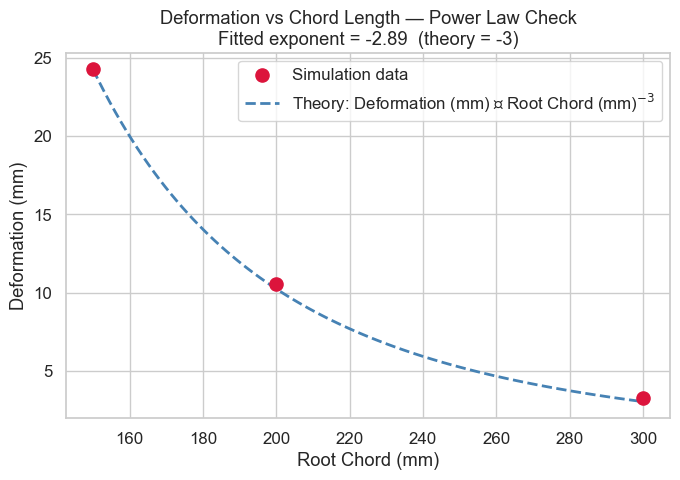

Font 'default' does not have a glyph for '\u221d' [U+221d], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u221d' [U+221d], substituting with a dummy symbol.


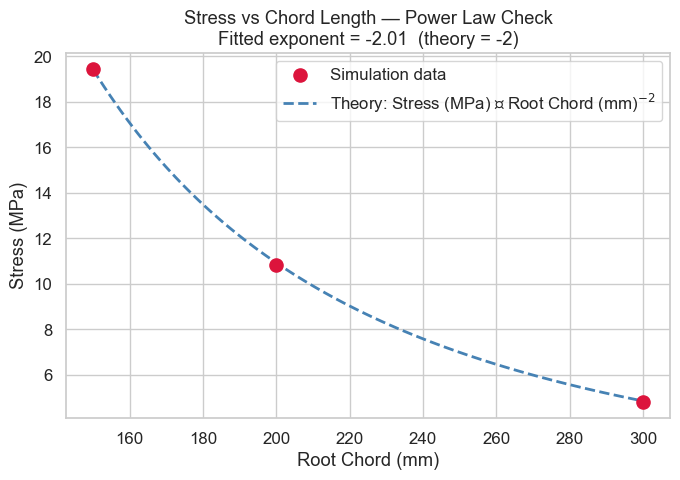

np.float64(-2.0074207952020484)

In [67]:
def plot_power_law_check(df, fixed_conds, x_col, y_col, theory_exponent, x_label, y_label, title):
    """
    Filters df to a fixed case (holding all other variables constant),
    overlays the actual data against the theoretical power-law curve,
    and reports the fitted exponent vs the theoretical one.
    """
    subset = df.copy()
    for col, val in fixed_conds.items():
        subset = subset[subset[col] == val]
    subset = subset.sort_values(x_col)

    x = subset[x_col].values
    y = subset[y_col].values

    # Fit exponent from the data (log-log linear regression)
    log_x, log_y = np.log(x), np.log(y)
    fitted_exponent, log_a = np.polyfit(log_x, log_y, 1)
    a = np.exp(log_a)

    # Theoretical curve anchored to the first data point
    x_theory = np.linspace(x.min(), x.max(), 100)
    y_theory = y[0] * (x_theory / x[0]) ** theory_exponent

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, color="crimson", s=90, zorder=3, label="Simulation data")
    plt.plot(x_theory, y_theory, "--", color="steelblue", linewidth=2,
             label=f"Theory: {y_label} ∝ {x_label}$^{{{theory_exponent}}}$")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f"{title}\nFitted exponent = {fitted_exponent:.2f}  (theory = {theory_exponent})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return fitted_exponent

# Blade Length cases (Material=Aluminium, Chord=200mm, Load=1000 Pa) 
fixed_bl = {"Material": "Aluminium", "Root_Chord_mm": 200, "Applied_Load_Pa": 1000}

plot_power_law_check(sim_data, fixed_bl, "Blade_Length_m", "Deformation_mm",
                      theory_exponent=4, x_label="Blade Length (m)", y_label="Deformation (mm)",
                      title="Deformation vs Blade Length — Power Law Check")

plot_power_law_check(sim_data, fixed_bl, "Blade_Length_m", "Stress_MPa",
                      theory_exponent=2, x_label="Blade Length (m)", y_label="Stress (MPa)",
                      title="Stress vs Blade Length — Power Law Check")

#  Chord Length cases (Material=Aluminium, Blade Length=1.2m, Load=1000 Pa) 
fixed_chord = {"Material": "Aluminium", "Blade_Length_m": 1.2, "Applied_Load_Pa": 1000}

plot_power_law_check(sim_data, fixed_chord, "Root_Chord_mm", "Deformation_mm",
                      theory_exponent=-3, x_label="Root Chord (mm)", y_label="Deformation (mm)",
                      title="Deformation vs Chord Length — Power Law Check")

plot_power_law_check(sim_data, fixed_chord, "Root_Chord_mm", "Stress_MPa",
                      theory_exponent=-2, x_label="Root Chord (mm)", y_label="Stress (MPa)",
                      title="Stress vs Chord Length — Power Law Check")